In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.preprocessing import LabelEncoder



# Load the dataset
url = r'/Users/Jonny/Desktop/ai_assignment_dataset/Telco-Customer-Churn.csv'
#path to dataset in eg  r'/Users/Jonny/Desktop/ai_assignment_dataset/Telco-Customer-Churn.csv'' format 


customers = pd.read_csv(url)




print("Dataset preview:\n", customers.head())




Dataset preview:
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

In [2]:
#------PRE PROCESSING -----------------



#Does the number of data and columns match the dataset
print("Dataset shape")
print(customers.shape) 
print("\n")

#looing for duplicate columns 
print("Columns in dataset")
print(customers.columns) 
print("\n")


print("column datatypes")
# View basic information about the dataset
print("column datatypes")
print(customers.info()) # Output: column names, data types, non-null counts









Dataset shape
(7043, 21)


Columns in dataset
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


column datatypes
column datatypes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   Mu

In [3]:
#Drope ID category




#drop ID category
customers.drop(columns=['customerID'], axis = 1,inplace=True) # Removing ID as it has no relevance to inference








print(customers.columns) 







Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [4]:
#White spaces in total charges


#white space counter in Total charges
non_numeric_mask = customers['TotalCharges'].astype(str).str.match(r'^\s*$')


count_of_bad_entries = non_numeric_mask.sum()

print(f"Total number of entries in 'TotalCharges' that are empty or only whitespace: {count_of_bad_entries}")





#convert all the values to Zero
customers['TotalCharges'] = pd.to_numeric(customers['TotalCharges'], errors='coerce')

# Fill the NaN values with 0


customers.fillna({'TotalCharges': 0}, inplace=True)












Total number of entries in 'TotalCharges' that are empty or only whitespace: 11


In [5]:
print("Missing values:\n", customers.isnull().sum()) # Shows count of missing values in each column










Missing values:
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
#------Encoding-----------#
#binary cateogries

# Binary columns to encode 
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    customers[col] = customers[col].replace({'Yes': 1, 'No': 0}).astype(int)

# Handle the 'gender' column separately (e.g., Male=1, Female=0)
customers['gender'] = customers['gender'].replace({'Male': 1, 'Female': 0}).astype(int)

# The original object columns are now numerical (0 or 1). No duplication occurs.

print(customers.info())   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   object 


/var/folders/7d/4kr0rhyx2c54f0j22w880vvc0000gp/T/ipykernel_59672/308038893.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  customers[col] = customers[col].replace({'Yes': 1, 'No': 0}).astype(int)
/var/folders/7d/4kr0rhyx2c54f0j22w880vvc0000gp/T/ipykernel_59672/308038893.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  customers[col] = customers[col].replace({'Yes': 1, 'No': 0}).astype(int)
/var/folders/7d/4kr0rhyx2c54f0j22w880vvc0000gp/T/ipykernel_59672/308038893.py:8: FutureWarning: Downcasting behavior in `replace` is dep

In [7]:

import pandas as pd

# The columns you provided
cols_to_encode = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod',
]

# Apply one-hot encoding, dropping the first category to avoid multicollinearity 
# WHAT Is it two or more predictor variables (features) in a regression model are highly correlated with each other.
customers = pd.get_dummies(
    customers,
    columns=cols_to_encode,
    dtype=int,
    drop_first=True
)

print(customers.info()) # Now prints info of the encoded DataFrame









<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

In [8]:
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd


y = customers['Churn']   #feature we are trying to predict 
X = customers.drop('Churn', axis=1)   #the rest of the data without Y


# Split data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
#startify beacuse the proportion of churn is much less 







numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# 2. Initialize the StandardScaler
scaler = StandardScaler()






# 3. FIT AND TRANSFORM the Training Data 
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features]) #scales the numerical values 



# 4. TRANSFORM the Testing Data 
X_test[numerical_features] = scaler.transform(X_test[numerical_features])  


print("Standardization Complete!")

print(f"Mean of 'tenure' in X_train_scaled: {X_train['TotalCharges'].mean():.2f}")
print(f"Standard Deviation of 'tenure' in X_train_scaled: {X_train['TotalCharges'].std():.2f}")





Standardization Complete!
Mean of 'tenure' in X_train_scaled: 0.00
Standard Deviation of 'tenure' in X_train_scaled: 1.00


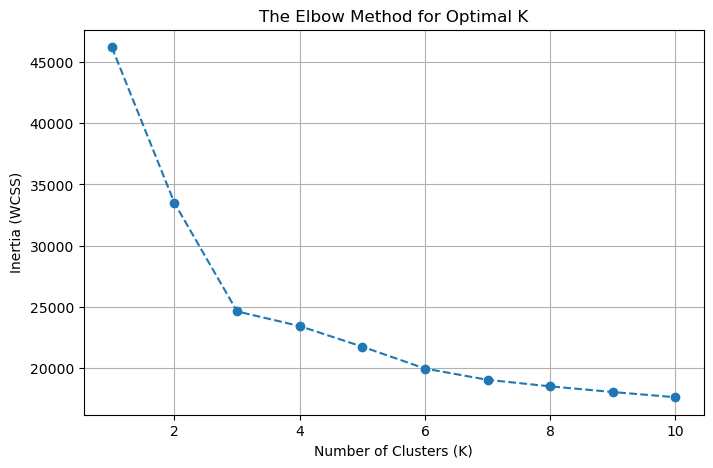

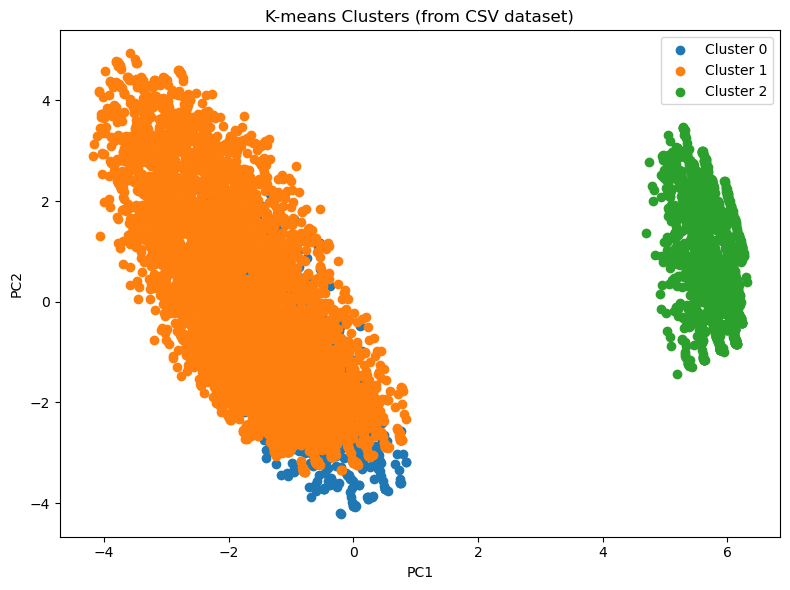

In [9]:

#elbow method for cluster size an dk means 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
k_range = range(1, 11) # Test k from 1 to 10

for k in k_range:
    # Set n_init to 'auto' or explicitly set a number greater than 1
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('The Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.grid(True)
plt.show()   




scaler = StandardScaler()
X_scale = scaler.fit_transform(X)

# ---------- 3. K-means clustering ----------
k = 3   # number of clusters (change as needed)
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scale)



#stan helped with this
# ---------- 4. Reduce to 2D for plotting ----------
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scale)

# ---------- 5. Plot clusters ----------
plt.figure(figsize=(8, 6))
for c in range(k):
    plt.scatter(
        X_2d[clusters == c, 0],
        X_2d[clusters == c, 1],
        label=f"Cluster {c}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means Clusters (from CSV dataset)")
plt.legend()
plt.tight_layout()
plt.show()






In [10]:
optimal_k = 1

# 1. Initialize and Fit the final K-Means model (on ALL scaled training data)
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto') 

# FIT on the ENTIRE X_train_scaled DataFrame, using all available features
final_kmeans.fit(X_train) 

# 2. Get cluster labels for the training set
X_train['Cluster_ID'] = final_kmeans.labels_

# 3. Predict cluster labels for the test set (using the model fitted on training data)
# PREDICT on the ENTIRE X_test_scaled DataFrame
X_test['Cluster_ID'] = final_kmeans.predict(X_test)





# 1. One-Hot Encode the Cluster_ID column
X_train = pd.get_dummies(X_train, columns=['Cluster_ID'], prefix='Cluster', drop_first=False)
X_test = pd.get_dummies(X_test, columns=['Cluster_ID'], prefix='Cluster', drop_first=False)



# The new features will be named 'Cluster_0', 'Cluster_1', 'Cluster_2', etc.
print(" Cluster_ID One-Hot Encoded and columns aligned.")


print(X_train.columns)






 Cluster_ID One-Hot Encoded and columns aligned.
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Cluster_0'],
      dtype='object')


In [11]:
##Training the data###


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd



# Initialize the Logistic Regression Model
# Solver='liblinear' is efficient for this size dataset.
# CRUCIAL: class_weight='balanced' is set to address the imbalance,
# giving more importance to the minority class (Churn) during training.
logreg = LogisticRegression(
    solver='liblinear',
    random_state=42,
    class_weight='balanced',
    C=2 #optimal value after the grid search 
)

# Train the model


logreg.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")





y_pred = logreg.predict(X_test)





Logistic Regression model trained successfully.


In [12]:
##random forest implementation 


# --- Random Forest Classifier Implementation ---
from sklearn.ensemble import RandomForestClassifier

# Define the model:
# n_estimators=100 (number of trees) is a good default.
# max_depth=10 prevents overfitting, focusing the trees on important patterns.
# class_weight='balanced' addresses the churn imbalance.
rf_model = RandomForestClassifier(
    n_estimators=100,    #number of decison trees
    random_state=42,
    class_weight='balanced',     
    max_depth=10,
    n_jobs=-1 
)

# Train the model
rf_model.fit(X_train, y_train)

# Save the trained model (for later evaluation)
# joblib.dump(rf_model, 'random_forest_model.pkl')

print(" Random Forest model trained successfully.")







 Random Forest model trained successfully.


In [13]:


# Get class predictions (0 or 1)
y_pred_rf = rf_model.predict(X_test)


'''
# Get prediction probabilities (probability of being class 1/Churn)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]  

'''

'\n# Get prediction probabilities (probability of being class 1/Churn)\ny_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]  \n\n'

logistic regression Classification Report
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Logistic regression overal Accuracy: 0.74
Logistic regression Precision: 0.51


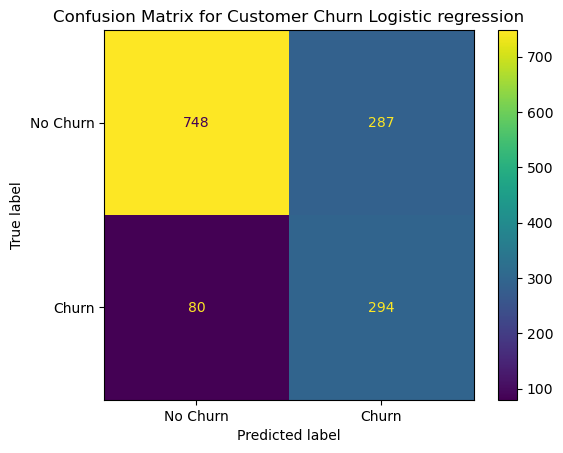

Random Forest Classification Report 
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.54      0.72      0.62       374

    accuracy                           0.77      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.77      0.77      1409

Random forest Overall Accuracy: 0.77
Random forest Overall Precision: 0.51


<Figure size 600x600 with 0 Axes>

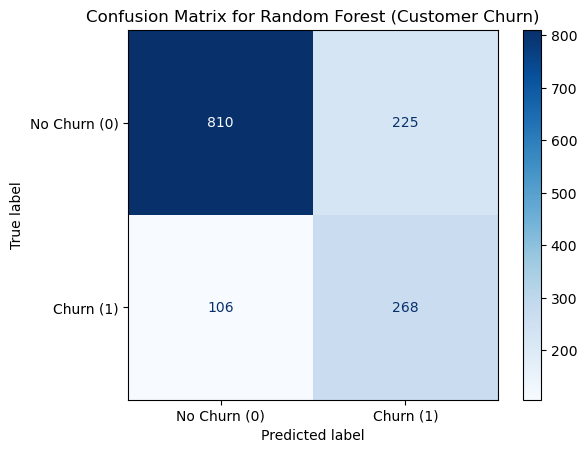

In [14]:
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay






print("logistic regression Classification Report")
# The report is calculated on the test set (y_test vs. y_pred_rf)
print(classification_report(y_test, y_pred))








##accuracy Logistic regression
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic regression overal Accuracy: {accuracy:.2f}")
precision = precision_score(y_test, y_pred)
print(f"Logistic regression Precision: {precision :.2f}")






# 2. Confusion matrix for logistic regression 
cm = confusion_matrix(y_test, y_pred, labels=logreg.classes_)

# 3. Visualize
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])







disp.plot()
plt.title('Confusion Matrix for Customer Churn Logistic regression')
plt.show()    





print("Random Forest Classification Report ")
# The report is calculated on the test set (y_test vs. y_pred_rf)
print(classification_report(y_test, y_pred_rf))

# Simple Accuracy (for general context)
accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random forest Overall Accuracy: {accuracy:.2f}")
print(f"Random forest Overall Precision: {precision :.2f}")


# 1. Random Forest predictions
# We use the unique values in y_test to define the labels (0 and 1)
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=[0, 1])

# 2. Visualize the Confusion Matrix
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Churn (0)', 'Churn (1)'])

plt.figure(figsize=(6, 6)) # Define figure size before plotting
disp_rf.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix for Random Forest (Customer Churn)')
plt.show()  

In [15]:


from sklearn.model_selection import GridSearchCV 




# Dictionary to store models and hyperparameters for optimization
model_params = {
    
    'random_forest': {
        'model': RandomForestClassifier(),  # Random Forest Classifier instance
        'params': {
            'n_estimators': [95, 100,105,110],  # Number of trees in the forest
            'max_depth': [10, 15, 25, 30],  # Maximum depth of the tree
            'min_samples_split': [5, 10]  # Minimum number of samples required to split an internal node
        }
    },
    
    'logistic_regression': {
        'model': LogisticRegression(solver='liblinear'),  # Logistic Regression instance
        'params': {
            'C': [0.5, 1.0, 1.5, 2.0, 5.0]  # Inverse of regularization strength
        }
    }
}



# List to store results of GridSearchCV
results = []  # Initialize an empty list to store model results

# Iterate through each model and its parameters
for model_name, mp in model_params.items():  # Loop through the model dictionary
    print(f"Training {model_name}...")  # Indicate which model is being trained

    # Initialize GridSearchCV with model, parameters, and cross-validation settings
    grid_search = GridSearchCV(mp['model'], mp['params'], cv=5, scoring='accuracy')  # Perform 5-fold cross-validation

    # Fit the GridSearchCV instance on the training data
    grid_search.fit(X_train, y_train)  # Train the model on the training data

    # Append model results to the results list
    results.append({
        'model': model_name,  # Name of the model
        'best_params': grid_search.best_params_,  # Best hyperparameters found
        'best_score': grid_search.best_score_  # Best cross-validation score
    })






Training random_forest...
Training logistic_regression...


In [16]:


for item in results:
    

    # 1. Iterate specifically over the keys of the dictionary 'item'
    for key in item:
         # This will print the key (e.g., 'model', 'best_params', 'best_score')
         print(f"{key}: {item[key]}")


model: random_forest
best_params: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
best_score: 0.8008493288426652
model: logistic_regression
best_params: {'C': 2.0}
best_score: 0.8047544448314502
